In [2]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
%matplotlib inline

sns.set_theme('notebook', palette='muted')


In [3]:
filename=r'D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\full_dataset.pkl'
dataset = pickle.load(open(filename,'rb'))
dataset


,Stock,Sector,Industry,MarketCap,Cap Category,Annualized_Return,Annualized_Volatility,Max_Drawdown,Avg_Volume,Volume_Spike_Pct,Beta_vs_NIFTY,Corr_with_NIFTY,Clusters,Categories
0,360ONE,Financial Services,Asset Management,445803167744,Mid Cap,3.524515,0.589975,30.097756,4.899030e+05,11.111111,0.639538,0.260950,2,Conservative
1,AARTIIND,Basic Materials,Specialty Chemicals,138456645632,Small Cap,-0.517008,0.585279,63.172265,1.300992e+06,7.317073,1.252114,0.514999,2,Conservative
2,ABB,Industrials,Specialty Industrial Machinery,1090798354432,Large Cap,2.615783,0.571198,26.442369,3.516467e+05,6.368564,0.862478,0.363485,2,Conservative
3,ABCAPITAL,Financial Services,Financial Conglomerates,781306822656,Mid Cap,0.639011,0.573486,35.630066,5.000453e+06,9.214092,1.392779,0.584635,2,Conservative
4,ABREL,Basic Materials,Paper & Paper Products,178644762624,Small Cap,2.476973,0.697101,39.647621,3.216849e+05,10.704607,1.227745,0.423973,2,Conservative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,WIPRO,Technology,Information Technology Services,2567080247296,Large Cap,-0.058463,0.432499,50.015772,1.370024e+07,5.555556,1.081205,0.601794,2,Conservative
263,WOCKPHARMA,Healthcare,Drug Manufacturers - Specialty & Generic,225707163648,Small Cap,4.216138,0.828349,63.056593,1.059813e+06,10.027100,0.982579,0.285548,0,Balanced
264,YESBANK,Financial Services,Banks - Regional,754220466176,Mid Cap,0.777135,0.707369,39.267516,1.655482e+08,10.569106,1.091840,0.371568,2,Conservative
265,ZENTEC,Industrials,Aerospace & Defense,125330620416,Small Cap,14.446618,0.809376,34.040224,5.798867e+05,10.840108,0.969627,0.288389,1,Aggressive


## 1. What is the Percent of Stocks by Categories

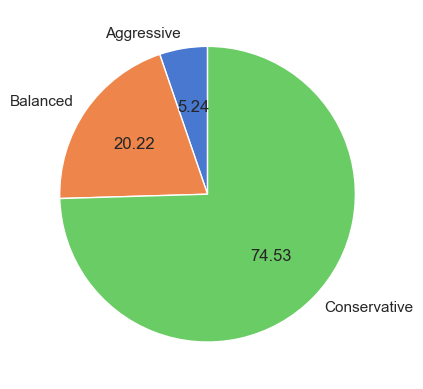

In [4]:
counts = dataset['Categories'].value_counts().sort_index()
labels = counts.index.tolist()
values = counts.values.tolist()

plt.pie(x=values, labels=labels, autopct='%.2f', startangle=90)
plt.show()


Most items are classified as Conservative (74.53%), which means majority of the items are in the safest category, indicating overall low risk.

## 2. What Sectors fall under each Risk-Reward Categories?

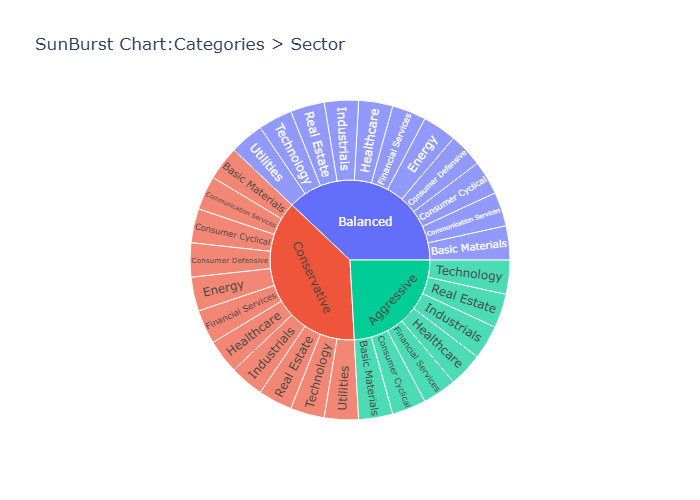

In [ ]:
stk_category=(dataset.groupby(['Categories','Sector']).count().reset_index()) [['Categories', 'Sector']]

fig_sunburst = px.sunburst(
    stk_category,
    path=['Categories', 'Sector'],
    title='SunBurst Chart:Categories > Sector',
    width=1100,
    height=600
)

# fig_sunburst.show()
fig_sunburst.write_image("plotly_chart.png")
from IPython.display import Image
Image("plotly_chart.png")


All risk categories—Balanced, Conservative, and Aggressive—contain stocks from a wide variety of sectors, showing that risk profile is diversified across industries.

## 3. What is Average Volume Distribution Across Risk Categories?

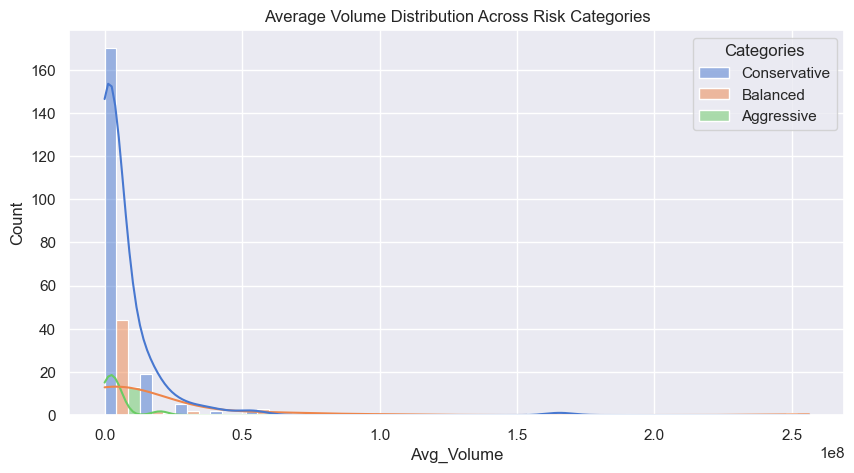

In [6]:
plt.figure(figsize=[10,5])
sns.histplot(dataset,x='Avg_Volume', hue='Categories', bins=20, kde=True, multiple='dodge')
plt.title('Average Volume Distribution Across Risk Categories')
plt.show()



Most of stocks have low average trading volumes, clustering at the lower end of the volume scale. However, only Conservative and Balanced stocks are rarely seen at very high average volumes.

## 4. What is Market Capitalization Distribution Across Risk Categories?

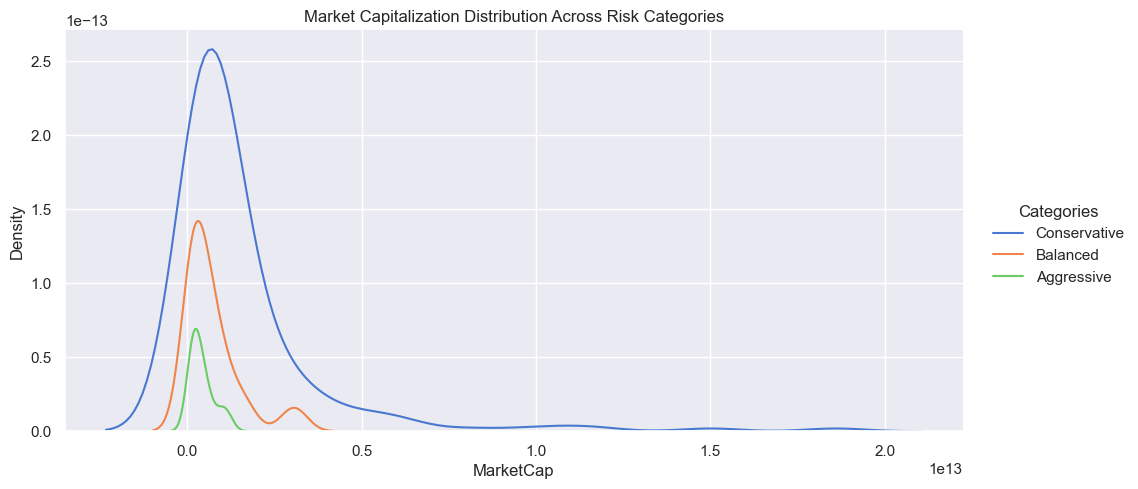

In [7]:
sns.displot(dataset,x='MarketCap', hue='Categories', kind='kde', aspect=2)
plt.title('Market Capitalization Distribution Across Risk Categories')
plt.show()


Conservative stocks tend to have much larger market capitalizations than balanced or aggressive stocks.

## 5. Compare the Risk Metrics Across each Categories

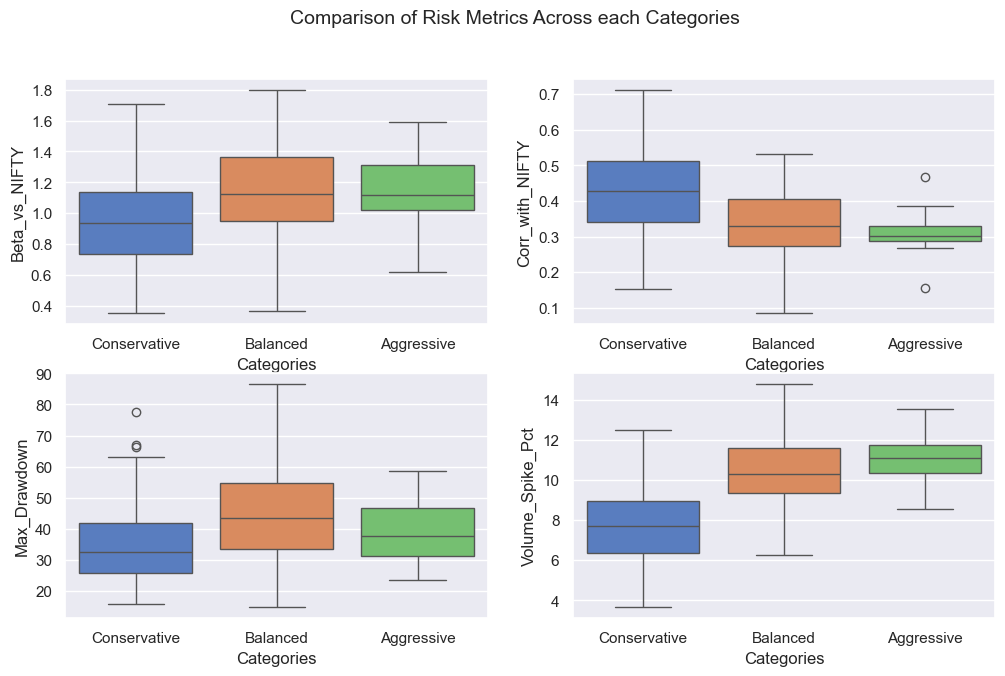

In [8]:
fig, axes = plt.subplots(2,2, figsize=[12,7])
sns.boxplot(dataset, x='Categories', y='Beta_vs_NIFTY', hue='Categories', ax=axes[0,0])
sns.boxplot(dataset, x='Categories', y='Corr_with_NIFTY', hue='Categories', ax=axes[0,1])
sns.boxplot(dataset, x='Categories', y='Max_Drawdown', hue='Categories', ax=axes[1,0])
sns.boxplot(dataset, x='Categories', y='Volume_Spike_Pct', hue='Categories', ax=axes[1,1])
fig.suptitle('Comparison of Risk Metrics Across each Categories', fontsize=14)
plt.show()


Aggressive stocks tend to have higher beta, lower correlation with Nifty, greater volume spikes, and larger drawdowns compared to conservative stocks, which generally have lower risk and more stable performance.

## 6. What is the Annualized Return Distribution on every Categories?

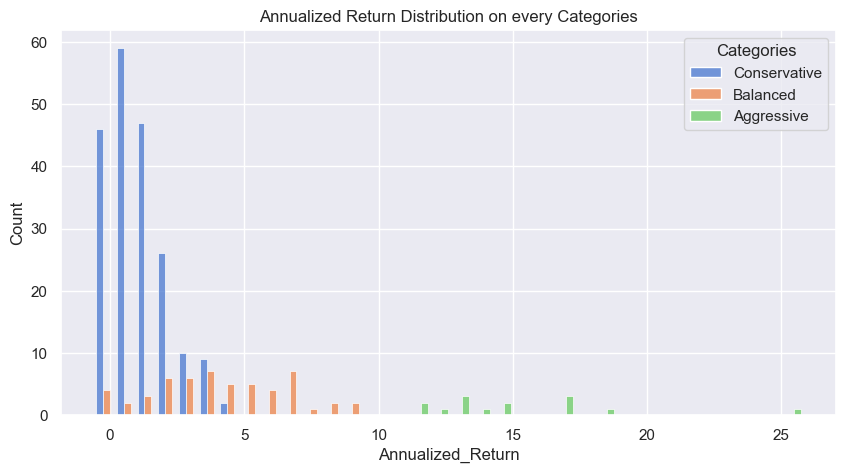

In [9]:
plt.figure(figsize=[10,5])
sns.histplot(dataset, x='Annualized_Return', hue='Categories', multiple='dodge')
plt.title('Annualized Return Distribution on every Categories')
plt.show()


Conservative stocks mostly have very low annualized returns, while aggressive stocks can achieve much higher returns.

## 7. What is the Relation between Market Cap Categories and Risk-Return Categories?

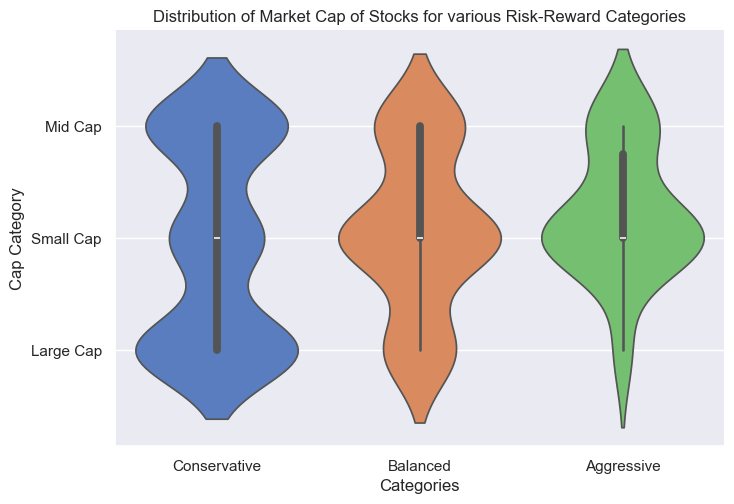

In [10]:
sns.catplot(dataset, x='Categories', y='Cap Category', hue='Categories', kind='violin', aspect=1.5)
plt.title('Distribution of Market Cap of Stocks for various Risk-Reward Categories')
plt.show()


All risk categories include a mix of large, mid, and small cap stocks, showing that company size does not strictly determine risk level. Also, aggressive and balanced stocks appear more frequently in the small cap category, while conservative stocks are more common among large and mid cap companies.

## 8.  Top 3 stocks with Highest and Lowest Max Drawdown on each Categories

In [11]:
categories = ['Conservative', 'Balanced', 'Aggressive']

for cat in categories:
    disp_data = dataset[dataset['Categories'] == cat][['Stock', 'Max_Drawdown']]
    print(f'\n{cat} Stocks\n')
    print('Top 3 Stocks with Highest Max Drawdown')
    print(disp_data.sort_values('Max_Drawdown', ascending=False).head(3).reset_index(drop=True))
    print('Top 3 Stocks with Lowest Max Drawdown')
    print(disp_data.sort_values('Max_Drawdown').head(3).reset_index(drop=True))



Conservative Stocks

Top 3 Stocks with Highest Max Drawdown
       Stock  Max_Drawdown
0      GLAND     77.554917
1      NYKAA     67.090047
2  PPLPHARMA     66.342101
Top 3 Stocks with Lowest Max Drawdown
       Stock  Max_Drawdown
0  SUNPHARMA     15.962300
1     MARICO     16.650211
2        ITC     16.839597

Balanced Stocks

Top 3 Stocks with Highest Max Drawdown
        Stock  Max_Drawdown
0        ATGL     86.455268
1  ADANIGREEN     84.440329
2        CGCL     77.910168
Top 3 Stocks with Lowest Max Drawdown
        Stock  Max_Drawdown
0  ANANDRATHI     14.894649
1         VBL     19.672531
2     INDIANB     21.371325

Aggressive Stocks

Top 3 Stocks with Highest Max Drawdown
        Stock  Max_Drawdown
0         BSE     58.695662
1  COCHINSHIP     54.568402
2        GRSE     49.221319
Top 3 Stocks with Lowest Max Drawdown
        Stock  Max_Drawdown
0  KALYANKJIL     23.597813
1      KAYNES     23.802488
2        HSCL     30.326869


## 9. Top 3 stocks with Highest and Lowest Total Annual Return on each Categories

In [64]:
categories = ['Conservative', 'Balanced', 'Aggressive']

for cat in categories:
    disp_data = dataset[dataset['Categories'] == cat][['Stock', 'Annualized_Return']]
    print(f'\n{cat} Stocks\n')
    print('Top 3 Stocks with Highest Annualized Return')
    print(disp_data.sort_values('Annualized_Return', ascending=False).head(3).reset_index(drop=True))
    print('Top 3 Stocks with Lowest Annualized Return')
    print(disp_data.sort_values('Annualized_Return').head(3).reset_index(drop=True))



Conservative Stocks

Top 3 Stocks with Highest Annualized Return
        Stock  Annualized_Return
0    INDHOTEL           4.601199
1    KFINTECH           4.283497
2  BLUESTARCO           4.006754
Top 3 Stocks with Lowest Annualized Return
      Stock  Annualized_Return
0  AARTIIND          -0.517008
1     GLAND          -0.409731
2     NYKAA          -0.404907

Balanced Stocks

Top 3 Stocks with Highest Annualized Return
    Stock  Annualized_Return
0    IRFC           8.957083
1  SUZLON           8.934834
2   HUDCO           8.614429
Top 3 Stocks with Lowest Annualized Return
  Stock  Annualized_Return
0  ATGL          -0.312451
1  IDEA          -0.228063
2  CGCL          -0.087710

Aggressive Stocks

Top 3 Stocks with Highest Annualized Return
     Stock  Annualized_Return
0  MAZDOCK          25.713159
1     RVNL          18.159442
2     PGEL          17.109775
Top 3 Stocks with Lowest Annualized Return
    Stock  Annualized_Return
0     BSE          11.482553
1    GRSE          11

## 10. What is the Correlation of the Categories with all input features

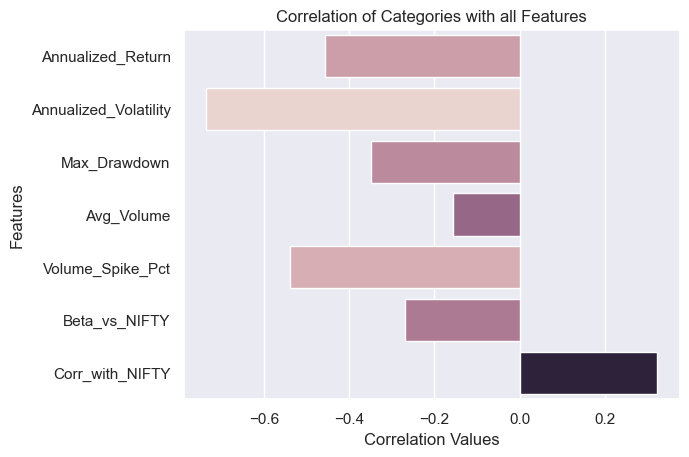

In [57]:
corr_inpcols = ['Annualized_Return', 'Annualized_Volatility', 'Max_Drawdown',
       'Avg_Volume', 'Volume_Spike_Pct', 'Beta_vs_NIFTY', 'Corr_with_NIFTY',
       'Clusters']
correlation = dataset[corr_inpcols].corr()['Clusters'][:-1]

sns.barplot(x=correlation.values, y=correlation.index, hue=correlation, errorbar=None, legend=False)
plt.xlabel('Correlation Values')
plt.ylabel('Features')
plt.title('Correlation of Categories with all Features')
plt.show()


Conservative=2, Aggressive=1, Balanced=0. Features with negative correlation are higher in aggressive stocks; features with positive correlation are higher in conservative stocks. 

So, Aggressive categories are negatively correlated with most risk and return features, except for correlation with NIFTY, which is positively correlated with Conservative Stocks.